Shape
(303, 14)

Columns
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

First 5 Rows
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
th

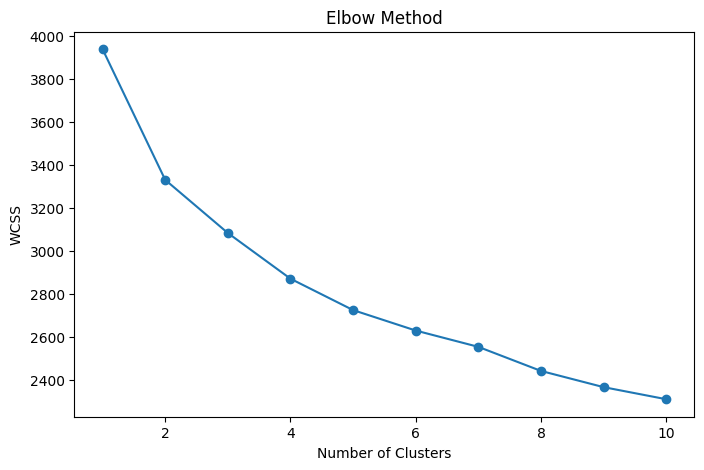


KMeans Silhouette Score
0.11385106870356003


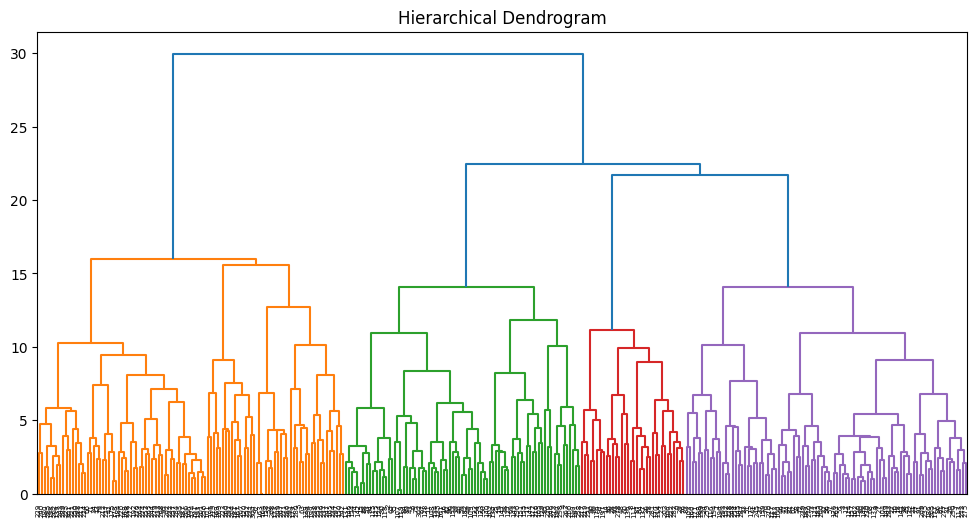


Hierarchical Score
0.09737426014314339

GMM Score
0.13798344216425631

First 5 Probability Rows
[[0.00000000e+00 0.00000000e+00 1.00000000e+00]
 [1.00000000e+00 0.00000000e+00 2.10184352e-27]
 [1.00000000e+00 0.00000000e+00 2.63816740e-41]
 [1.00000000e+00 0.00000000e+00 5.21043049e-24]
 [8.16611682e-03 9.91833883e-01 1.30416024e-20]]


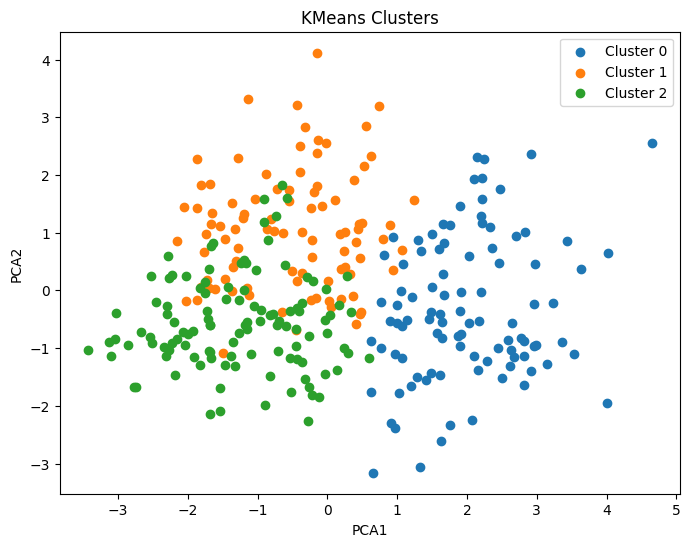

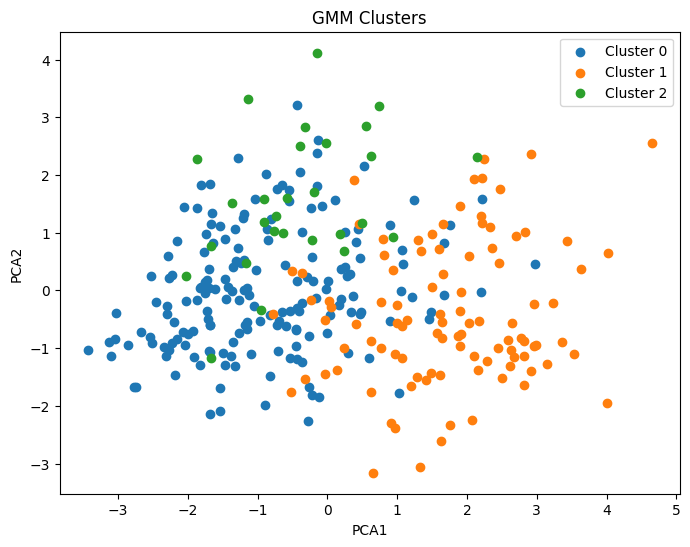


File Saved Successfully


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

df = pd.read_csv("heart.csv")

print("Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nFirst 5 Rows")
print(df.head())

print("\nMissing Values")
print(df.isnull().sum())

X = df.drop("target", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("\nKMeans Silhouette Score")

print(
    silhouette_score(
        X_scaled,
        kmeans_labels
    )
)

linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Dendrogram")

plt.show()

hierarchical = AgglomerativeClustering(
    n_clusters=3
)

hier_labels = hierarchical.fit_predict(
    X_scaled
)

print("\nHierarchical Score")

print(
    silhouette_score(
        X_scaled,
        hier_labels
    )
)

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(X_scaled)

gmm_labels = gmm.predict(
    X_scaled
)

print("\nGMM Score")

print(
    silhouette_score(
        X_scaled,
        gmm_labels
    )
)

probability = gmm.predict_proba(
    X_scaled
)

print("\nFirst 5 Probability Rows")

print(probability[:5])

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))

for i in range(3):

    plt.scatter(
        X_pca[kmeans_labels == i,0],
        X_pca[kmeans_labels == i,1],
        label=f'Cluster {i}'
    )

plt.title("KMeans Clusters")

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.legend()

plt.show()

plt.figure(figsize=(8,6))

for i in range(3):

    plt.scatter(
        X_pca[gmm_labels == i,0],
        X_pca[gmm_labels == i,1],
        label=f'Cluster {i}'
    )

plt.title("GMM Clusters")

plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.legend()

plt.show()

df["KMeans_Cluster"] = kmeans_labels

df["Hierarchical_Cluster"] = hier_labels

df["GMM_Cluster"] = gmm_labels

df.to_csv(
    "heart_cluster_results.csv",
    index=False
)

print("\nFile Saved Successfully")